In [95]:
#!pip install xarray
#!pip install scipy
#!pip install cdsapi

#### Import Libraries

In [96]:
import xarray as xr
import numpy as np
import pandas as pd
import marineHeatWaves as mhw
import datetime as dt
import math

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import griddata
from matplotlib.gridspec import GridSpec

#### Define Slice Function

The coordinates have to be defined in 0-360 format.

In [97]:
def spatial_subset(ds):
    out = ds.sel(lon = slice(350.0, 355.0),
                 lat = slice(36.0, 42.3))
    return out

## Get Baseline

The baselilne used is 1991-2021

In [98]:
baseline_df = pd.DataFrame()
for year in range(1991, 2022):

    var = xr.open_dataset(f"oisst_daily/sst.day.mean.{year}.nc", 
                        engine="netcdf4", decode_times=True)
    
    print(f'Opening {year}')
    
    var_sel = spatial_subset(var)
    
    var_sst = var_sel["sst"]

    baseline_df = pd.concat([baseline_df, var_sst.to_dataframe()])
    
del var

Opening 1991
Opening 1992
Opening 1993
Opening 1994
Opening 1995
Opening 1996
Opening 1997
Opening 1998
Opening 1999
Opening 2000
Opening 2001
Opening 2002
Opening 2003
Opening 2004
Opening 2005
Opening 2006
Opening 2007
Opening 2008
Opening 2009
Opening 2010
Opening 2011
Opening 2012
Opening 2013
Opening 2014
Opening 2015
Opening 2016
Opening 2017
Opening 2018
Opening 2019
Opening 2020
Opening 2021


## Years to be Analysed

In [113]:
y2018 = xr.open_dataset("oisst_daily/sst.day.mean.2018.nc", 
                        engine="netcdf4", decode_times=True)
y2019 = xr.open_dataset("oisst_daily/sst.day.mean.2019.nc", 
                        engine="netcdf4", decode_times=True)
y2020 = xr.open_dataset("oisst_daily/sst.day.mean.2020.nc", 
                        engine="netcdf4", decode_times=True)
y2021 = xr.open_dataset("oisst_daily/sst.day.mean.2021.nc", 
                        engine="netcdf4", decode_times=True)
y2022 = xr.open_dataset("oisst_daily/sst.day.mean.2022.nc", 
                        engine="netcdf4", decode_times=True)
y2023 = xr.open_dataset("oisst_daily/sst.day.mean.2023.nc", 
                        engine="netcdf4", decode_times=True)
y2024 = xr.open_dataset("oisst_daily/sst.day.mean.2024.nc", 
                        engine="netcdf4", decode_times=True)
y2025 = xr.open_dataset("oisst_daily/sst.day.mean.2025.nc", 
                        engine="netcdf4", decode_times=True)

#### Slice datasets' coordinates

In [100]:
y2018_sel = spatial_subset(y2018)
y2018_sst = y2018_sel["sst"]
y2018_time = y2018_sel["time"]

y2019_sel = spatial_subset(y2019)
y2019_sst = y2019_sel["sst"]
y2019_time = y2019_sel["time"]

y2020_sel = spatial_subset(y2020)
y2020_sst = y2020_sel["sst"]
y2020_time = y2020_sel["time"]

y2021_sel = spatial_subset(y2021)
y2021_sst = y2021_sel["sst"]
y2021_time = y2021_sel["time"]

y2022_sel = spatial_subset(y2022)
y2022_sst = y2022_sel["sst"]
y2022_time = y2022_sel["time"]

y2023_sel = spatial_subset(y2023)
y2023_sst = y2023_sel["sst"]
y2023_time = y2023_sel["time"]

y2024_sel = spatial_subset(y2024)
y2024_sst = y2024_sel["sst"]
y2024_time = y2024_sel["time"]

y2025_sel = spatial_subset(y2025)
y2025_sst = y2025_sel["sst"]
y2025_time = y2025_sel["time"]

In [101]:
baseline_df = baseline_df.reset_index()

y2018_df = y2018_sst.to_dataframe().reset_index()
y2019_df = y2019_sst.to_dataframe().reset_index()
y2020_df = y2020_sst.to_dataframe().reset_index()
y2021_df = y2021_sst.to_dataframe().reset_index()
y2022_df = y2022_sst.to_dataframe().reset_index()
y2023_df = y2023_sst.to_dataframe().reset_index()
y2024_df = y2024_sst.to_dataframe().reset_index()
y2025_df = y2025_sst.to_dataframe().reset_index()

## Conversion to ordinal time

In [102]:
def to_ordinal(time_array):
    ordinals = []

    for t in time_array:
        # Case 1: numpy.datetime64
        if isinstance(t, np.datetime64):
            ts = pd.Timestamp(t)
            ordinals.append(ts.to_pydatetime().date().toordinal())

        # Case 2: cftime objects
        else:
            ordinals.append(dt.date(t.year, t.month, t.day).toordinal())

    return np.array(ordinals)

## Detect MHWs

In [103]:
def detect_mhw_year(year_df, baseline_df, climatology_period=(1991, 2021)):
    
    results = []

    for (lat, lon), group_year in year_df.groupby(["lat", "lon"]):

        # --- year data ---
        y_sst = group_year["sst"].values
        y_time = group_year["time"].values
        y_time_ord = to_ordinal(y_time)

        # --- baseline for same grid cell ---
        base_group = baseline_df[
            (baseline_df["lat"] == lat) &
            (baseline_df["lon"] == lon)
        ]

        if base_group.empty:
            continue

        base_sst = base_group["sst"].values
        base_time = base_group["time"].values
        base_time_ord = to_ordinal(base_time)

        base_years = pd.to_datetime(base_time).year

        if (base_years.min() > climatology_period[0] or
            base_years.max() < climatology_period[1]):
            continue

        # --- MHW detection ---
        mhw_ev, clim = mhw.detect(
            y_time_ord,
            y_sst,
            climatologyPeriod= list(climatology_period),
            alternateClimatology= [base_time_ord, base_sst]
        )

        results.append({
            "year": pd.to_datetime(y_time[0]).year,
            "lat": lat,
            "lon": lon,
            "n_events": mhw_ev["n_events"],
            "total_duration": (
                np.sum(mhw_ev["duration"])
            ),
            "max_intensity": (
                np.max(mhw_ev["intensity_max"])
                if mhw_ev["n_events"] > 0 else np.nan
            )
        })

    return pd.DataFrame(results)


In [ ]:
df_2018 = detect_mhw_year(y2018_df, baseline_df)
df_2019 = detect_mhw_year(y2019_df, baseline_df)
df_2020 = detect_mhw_year(y2020_df, baseline_df)
df_2021 = detect_mhw_year(y2021_df, baseline_df)
df_2022 = detect_mhw_year(y2022_df, baseline_df)
df_2023 = detect_mhw_year(y2023_df, baseline_df)
df_2024 = detect_mhw_year(y2024_df, baseline_df)
df_2025 = detect_mhw_year(y2025_df, baseline_df)

yearly_dfs = {
    2018: df_2018,
    2019: df_2019,
    2020: df_2020,
    2021: df_2021,
    2022: df_2022,
    2023: df_2023,
    2024: df_2024,
    2025: df_2025
}

/opt/anaconda3/envs/MHW/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1406: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
/Users/miguelsilveira/Documents/GitHub/marineheatwaves/marineHeatWaves.py:281: RuntimeWarning: Mean of empty slice
  seas_climYear[d-1] = np.nanmean(tempClim[tt.astype(int)])
/Users/miguelsilveira/Documents/GitHub/marineheatwaves/marineHeatWaves.py:411: RuntimeWarning: invalid value encountered in scalar divide
  mhw['rate_decline'].append((mhw_relSeas[tt_peak] - mhw_relSeas[-1]) / (tt_end-tt_start-tt_peak))
/opt/anaconda3/envs/MHW/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1406: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
/Users/miguelsilveira/Documents/GitHub/marineheatwaves/marineHeatWaves.py:281: RuntimeWarning: Mean of empty slice
  seas_climYear[d-1] = np.nanmean(tempClim[tt.astype(int)])
/opt/anaconda3/envs/MHW/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl

## Graphs

#### By number of events

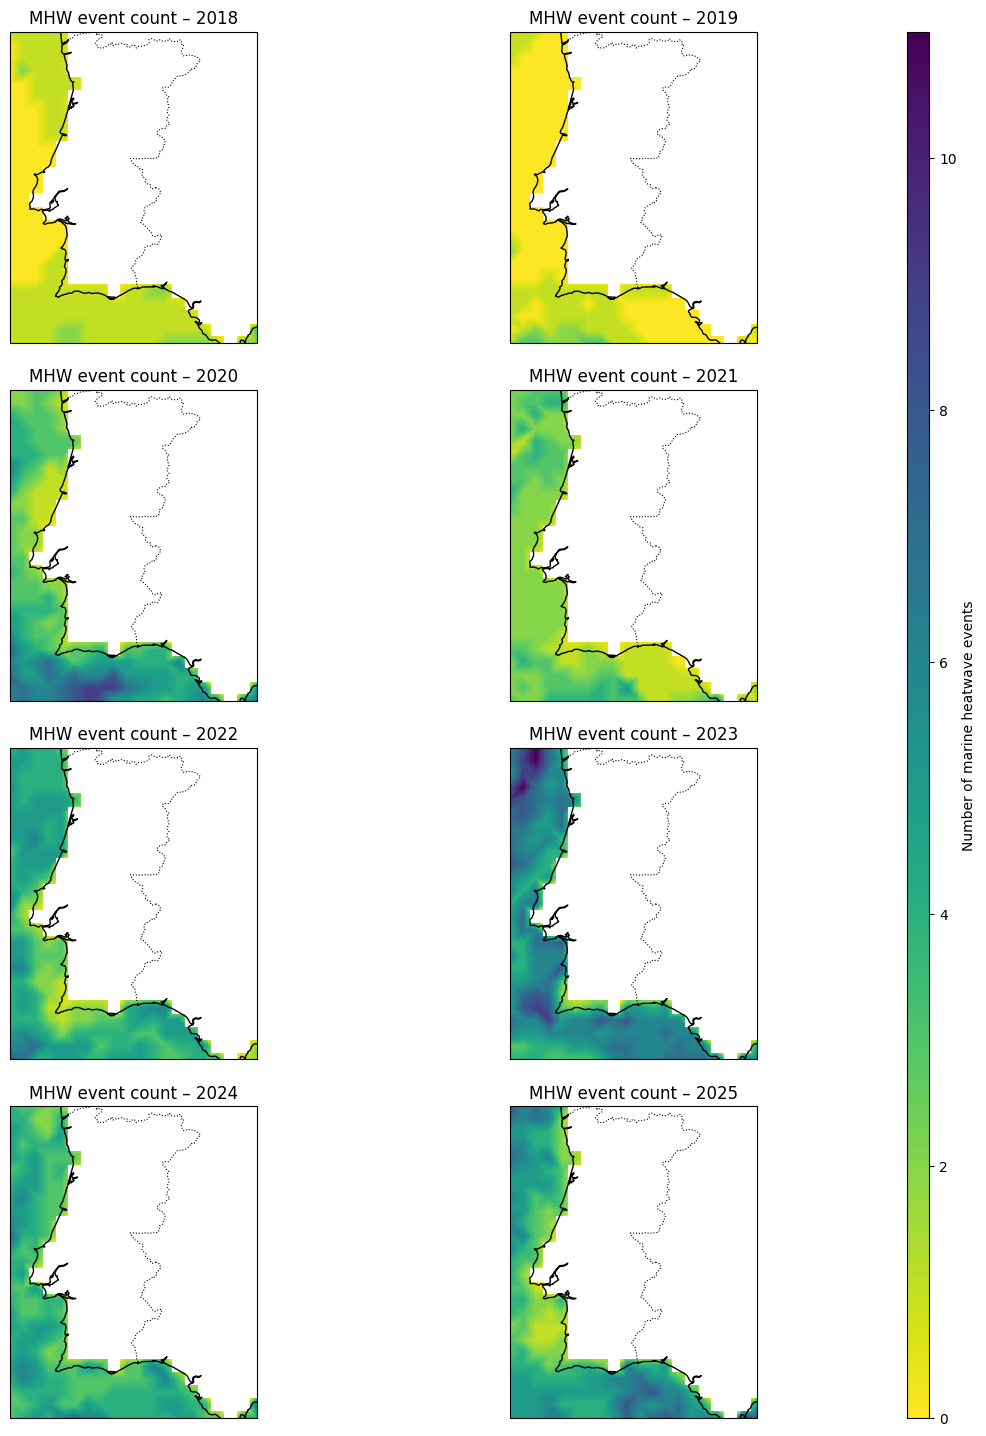

In [ ]:
ds_mask = y2022_sel

# =================================================
# TRUE ocean mask (True = ocean, False = land)
# =================================================
ocean_mask = ~np.isnan(ds_mask["sst"].isel(time=0))

lon_mask = ds_mask["lon"].values
lat_mask = ds_mask["lat"].values
lon2d_mask, lat2d_mask = np.meshgrid(lon_mask, lat_mask)

# =================================================
# Shared interpolation grid (based on all data)
# =================================================
all_lons = np.concatenate([df["lon"].values for df in yearly_dfs.values()])
all_lats = np.concatenate([df["lat"].values for df in yearly_dfs.values()])

lon_grid = np.linspace(all_lons.min(), all_lons.max(), 300)
lat_grid = np.linspace(all_lats.min(), all_lats.max(), 300)
lon_grid, lat_grid = np.meshgrid(lon_grid, lat_grid)

# =================================================
# Interpolate land–sea mask ONCE
# =================================================
mask_interp = griddata(
    (lon2d_mask.ravel(), lat2d_mask.ravel()),
    ocean_mask.values.ravel().astype(float),
    (lon_grid, lat_grid),
    method="nearest"
)

# =================================================
# Figure layout (SCALABLE)
# =================================================
n_panels = len(yearly_dfs)
ncols = 2
nrows = math.ceil(n_panels / ncols)

fig = plt.figure(figsize=(6 * ncols + 1.2, 4.5 * nrows))

gs = GridSpec(
    nrows,
    ncols + 1,
    width_ratios=[1] * ncols + [0.05],
    wspace=0.15,
    hspace=0.15
)

axes = []
for i in range(n_panels):
    r = i // ncols
    c = i % ncols
    ax = fig.add_subplot(gs[r, c], projection=ccrs.PlateCarree())
    axes.append(ax)

cax = fig.add_subplot(gs[:, -1])

# =================================================
# Shared color scale
# =================================================
vmin = 0
vmax = max(df["n_events"].max() for df in yearly_dfs.values())

# =================================================
# Plot each year
# =================================================
for ax, (year, df) in zip(axes, yearly_dfs.items()):

    lons = df["lon"].values
    lats = df["lat"].values
    counts = df["n_events"].values

    # Linear interpolation
    grid_counts = griddata(
        (lons, lats),
        counts,
        (lon_grid, lat_grid),
        method="linear"
    )

    # Nearest fallback (fills coastal gaps)
    grid_counts_nearest = griddata(
        (lons, lats),
        counts,
        (lon_grid, lat_grid),
        method="nearest"
    )

    grid_counts = np.where(
        np.isnan(grid_counts),
        grid_counts_nearest,
        grid_counts
    )

    # Apply land mask
    grid_counts = np.ma.masked_where(mask_interp < 0.5, grid_counts)

    # Map styling
    ax.set_extent(
        [all_lons.min(), all_lons.max(), all_lats.min(), all_lats.max()],
        crs=ccrs.PlateCarree()
    )

    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.8)

    mesh = ax.pcolormesh(
        lon_grid,
        lat_grid,
        grid_counts,
        cmap="viridis_r",
        shading="auto",
        vmin=vmin,
        vmax=vmax,
        transform=ccrs.PlateCarree()
    )

    ax.set_title(f"MHW event count - {year}")

# =================================================
# Shared colorbar
# =================================================
cbar = fig.colorbar(mesh, cax=cax)
cbar.set_label("Number of marine heatwave events")

plt.show()

#### By total duration

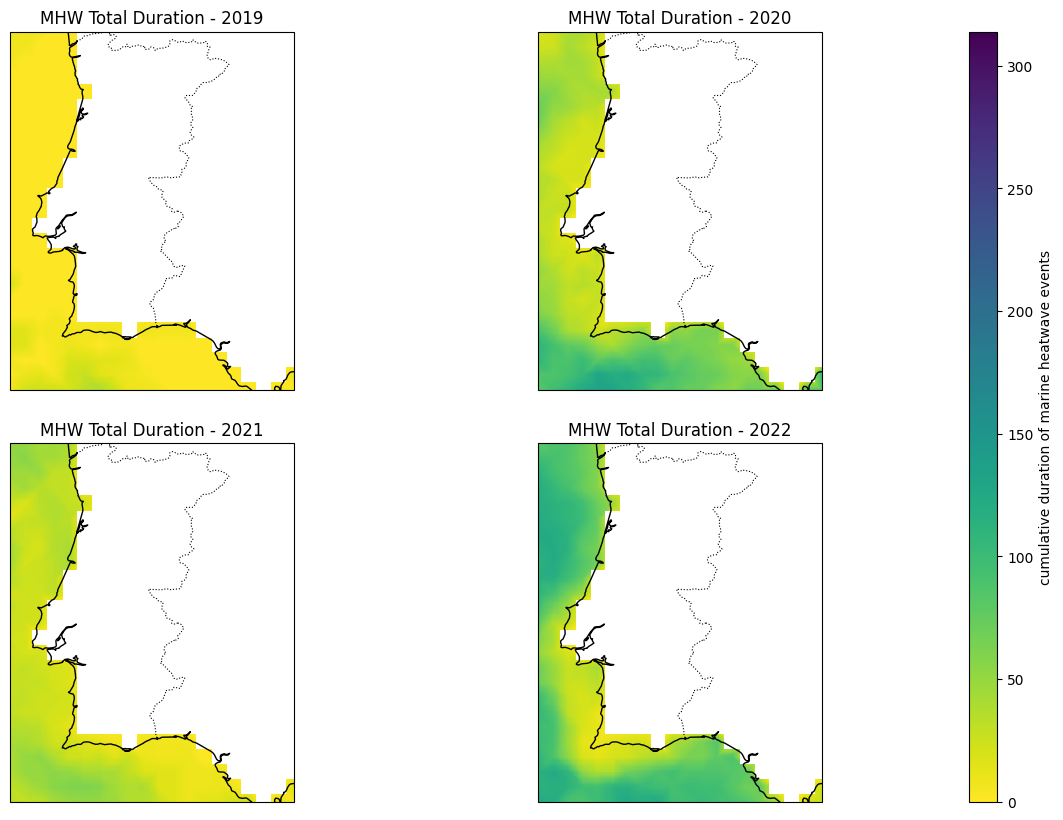

In [107]:
# -------------------------------------------------
# Figure layout (explicit, no overlap)
# -------------------------------------------------
fig = plt.figure(figsize=(14, 10))
gs = GridSpec(2, 3, width_ratios=[1, 1, 0.06], wspace=0.15, hspace=0.15)

axes = [
    fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree()),
    fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree()),
]

cax = fig.add_subplot(gs[:, 2])  # colorbar axis

# -------------------------------------------------
# Shared color scale
# -------------------------------------------------
vmin = 0
vmax = max(df["total_duration"].max() for df in yearly_dfs.values())


# -------------------------------------------------
# Plot each year
# -------------------------------------------------
for ax, (year, df) in zip(axes, yearly_dfs.items()):

    lats = df["lat"].values
    lons = df["lon"].values
    counts = df["total_duration"].values

    # Interpolation grid
    lon_grid = np.linspace(lons.min(), lons.max(), 300)
    lat_grid = np.linspace(lats.min(), lats.max(), 300)
    lon_grid, lat_grid = np.meshgrid(lon_grid, lat_grid)

    # -----------------------------
    # Interpolate MHW counts
    # -----------------------------
    grid_counts = griddata(
        (lons, lats),
        counts,
        (lon_grid, lat_grid),
        method="linear"
    )

    # -----------------------------
    # Interpolate TRUE land–sea mask
    # -----------------------------
    # -------------------------------------------------
    # Build lon/lat grid from the SST mask dataset
    # -------------------------------------------------
    lon2d, lat2d = np.meshgrid(
        ds_mask["lon"].values,
        ds_mask["lat"].values
    )

    # -------------------------------------------------
    # Interpolate TRUE land–sea mask
    # -------------------------------------------------
    mask_interp = griddata(
        (lon2d.ravel(), lat2d.ravel()),
        ocean_mask.values.ravel().astype(float),
        (lon_grid, lat_grid),
        method="nearest"
    )

    # Apply mask
    grid_counts = np.ma.masked_where(mask_interp < 0.5, grid_counts)


    # Apply mask (THIS removes the triangle)
    grid_counts = np.ma.masked_where(mask_interp < 0.5, grid_counts)

    # -----------------------------
    # Map styling
    # -----------------------------
    ax.set_extent(
        [lons.min(), lons.max(), lats.min(), lats.max()],
        crs=ccrs.PlateCarree()
    )

    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.8)

    mesh = ax.pcolormesh(
        lon_grid,
        lat_grid,
        grid_counts,
        cmap="viridis_r",
        shading="auto",
        vmin=vmin,
        vmax=vmax,
        transform=ccrs.PlateCarree()
    )

    ax.set_title(f"MHW Total Duration - {year}")

# -------------------------------------------------
# Colorbar (guaranteed no overlap)
# -------------------------------------------------
cbar = fig.colorbar(mesh, cax=cax)
cbar.set_label("cumulative duration of marine heatwave events")


plt.show()